In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

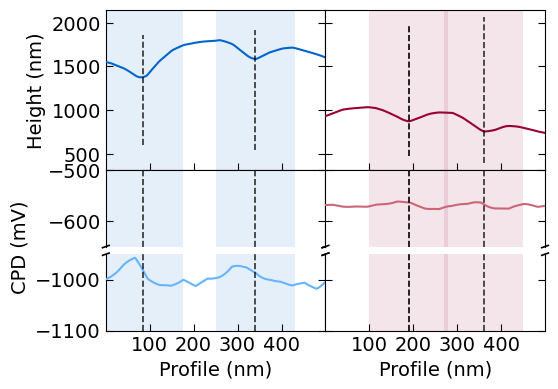

In [14]:
def separate_data(file_path, number):
    open(file_path, 'r', encoding='utf-8', errors='replace')
    data = np.loadtxt(file_path, skiprows=3)
    x_data = data[:, 0]
    y_data = data[:, 1]
    x_data_new=np.round(x_data*10**9, 4)
    y_data_new=np.round(y_data*number,4)
    return x_data_new, y_data_new
# ---------------------------------------------------------
# 1. Generate Dummy Data (to match the shape of the curves)
# ---------------------------------------------------------
x = np.linspace(0, 500, 200)

# Unpassivated Data (Left Column)
height_unpass = 20 + 20 * np.sin(x/50) + 5 * np.cos(x/20) - (x/50)
cpd_unpass = -1050 + 40 * np.sin((x+20)/30) * np.exp(-x/300)

# Passivated Data (Right Column)
height_pass = 20 + 12 * np.sin((x+50)/40) + 4 * np.cos(x/15) - (x/30)
cpd_pass = -580 + 10 * np.sin(x/40)

# ---------------------------------------------------------
# 1. Load data 
# ---------------------------------------------------------
unpass_height=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\Line Profile\CTRL\250422_RG0087_0001_Height_ROI.txt"
unpass_cpd=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\Line Profile\CTRL\250422_RG0087_0001_CPD_ROI.txt"
pass_height=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\Line Profile\AEAPTMS\X251023_RG0094_0001_height_ROI.txt"
pass_cpd=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\Line Profile\AEAPTMS\X251023_RG0094_0001_CPD_ROI.txt"

x_unpass, height_unpass = separate_data(unpass_height,10e9)

x_unpass, cpd_unpass = separate_data(unpass_cpd, 1000)

x_pass, height_pass = separate_data(pass_height, 10e9)

x_pass, cpd_pass = separate_data(pass_cpd, 1000)



# ---------------------------------------------------------
# 2. Figure Setup
# ---------------------------------------------------------
base_font_size = 14
plt.rcParams.update({'font.size': base_font_size, 'font.family': 'sans-serif'})
dpi_settings= 600
figsize_x, figsize_y = (3400/dpi_settings), (2500/dpi_settings)
fig = plt.figure(figsize=(figsize_x, figsize_y))

# Main grid: 2 columns. We split the rows manually.
gs_main = plt.GridSpec(2, 2, height_ratios=[1, 1], hspace=0, wspace=0)

# Top Row (Height - Unbroken)
ax1 = fig.add_subplot(gs_main[0, 0])
ax2 = fig.add_subplot(gs_main[0, 1], sharex=ax1, sharey=ax1)

# Bottom Row (CPD - Broken Axes via subgridspec)
gs_bot_left = gs_main[1, 0].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.1)
gs_bot_right = gs_main[1, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.1)

ax3_top = fig.add_subplot(gs_bot_left[0], sharex=ax1)
ax3_bot = fig.add_subplot(gs_bot_left[1], sharex=ax1)
ax4_top = fig.add_subplot(gs_bot_right[0], sharex=ax2, sharey=ax3_top)
ax4_bot = fig.add_subplot(gs_bot_right[1], sharex=ax2, sharey=ax3_bot)

# ---------------------------------------------------------
# 3. Plotting the Lines
# ---------------------------------------------------------
line_lw = 1.5

# Height Data
ax1.plot(x_unpass, height_unpass, color='#0066cc', lw=line_lw, zorder=3) # Blue
ax2.plot(x_pass, height_pass, color='#990033', lw=line_lw, zorder=3)     # Dark Red

# CPD Data (Unpassivated) - Plotted on both top and bottom
ax3_top.plot(x_unpass, cpd_unpass, color='#66b3ff', lw=line_lw, zorder=3)
ax3_bot.plot(x_unpass, cpd_unpass, color='#66b3ff', lw=line_lw, zorder=3)

# CPD Data (Passivated) - Plotted on both top and bottom
ax4_top.plot(x_pass, cpd_pass, color='#cc6677', lw=line_lw, zorder=3)
ax4_bot.plot(x_pass, cpd_pass, color='#cc6677', lw=line_lw, zorder=3)

# ---------------------------------------------------------
# 4. Axis Limits and Formatting the Break
# ---------------------------------------------------------
ax1.set_xlim(0, 500)
# Height limits will autoscale, or you can uncomment below to force them:
# ax1.set_ylim(-10, 50)

# --- IMPORTANT: ADJUST THESE LIMITS FOR YOUR SPECIFIC CPD DATA ---
ax3_top.set_ylim(-650, -500)   # Upper section of the broken axis
ax3_bot.set_ylim(-1100, -950)  # Lower section of the broken axis

# Hide the spines between the broken sections
for ax in [ax3_top, ax4_top]:
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

for ax in [ax3_bot, ax4_bot]:
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='x', top=False)

# Draw the diagonal break marks (//)
def draw_breaks(ax_top, ax_bot):
    d = 0.015  # Size of the diagonal line
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, lw=1.2)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)        # Top-left bottom
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right bottom
    
    kwargs.update(transform=ax_bot.transAxes)        # Switch to bottom axes
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left top
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right top

draw_breaks(ax3_top, ax3_bot)
draw_breaks(ax4_top, ax4_bot)

# ---------------------------------------------------------
# 5. Adding the Shaded Regions (axvspan)
# ---------------------------------------------------------
# Unpassivated highlights (blue theme)
for ax in [ax1, ax3_top, ax3_bot]:
    ax.axvspan(85-90, 85+90, facecolor='#0066cc', alpha=0.1, zorder=2)
    ax.axvspan(340-90, 340+90, facecolor='#0066cc', alpha=0.1, zorder=2)
    ax.vlines(85, *ax.get_ylim(), color='black', linestyles='--', alpha=0.8,lw=1.2, zorder=4)
    ax.vlines(340, *ax.get_ylim(), color='black', linestyles='--', alpha=0.8, lw=1.2, zorder=4)

# Passivated highlights (red theme)
for ax in [ax2, ax4_top, ax4_bot]:
    ax.axvspan(190-90, 190+90, facecolor='#990033', alpha=0.1, zorder=2)
    ax.axvspan(360-90, 360+90, facecolor='#990033', alpha=0.1, zorder=2)
    ax.vlines(190, *ax.get_ylim(), color='black', linestyles='--', lw=1.2, zorder=4)
    ax.vlines(360, *ax.get_ylim(), color='black', linestyles='--', alpha=0.8, lw=1.2, zorder=4)

# ---------------------------------------------------------
# 6. Labels, Titles, and Text Annotations
# ---------------------------------------------------------
#ax1.set_title('Unpassivated', fontweight='bold', pad=15)
#ax2.set_title('Passivated', fontweight='bold', pad=15)

ax1.set_ylabel('Height (nm)')
# Center the CPD label across the broken axes
ax3_top.set_ylabel('CPD (mV)')
ax3_top.yaxis.set_label_coords(-0.35, 0) 

ax3_bot.set_xlabel('Profile (nm)')
ax4_bot.set_xlabel('Profile (nm)')

#Inner panel lettering (e, f, g, h) - Un-comment when ready!
""" text_kwargs = dict(fontweight='bold', fontsize=12, va='center', ha='right')
ax1.text(0.98, 0.08, '(e)', transform=ax1.transAxes, **text_kwargs)
ax3_top.text(0.98, 0.92, '(f)', transform=ax3_top.transAxes, **text_kwargs)
ax2.text(0.02, 0.08, '(g)', transform=ax2.transAxes, ha='left', fontweight='bold', fontsize=12)
ax4_top.text(0.02, 0.92, '(h)', transform=ax4_top.transAxes, ha='left', fontweight='bold', fontsize=12)
 """
# ---------------------------------------------------------
# 7. Global Tick Formatting
# ---------------------------------------------------------
for ax in fig.get_axes():
    ax.tick_params(direction='in', left=True, right=True, length=5)
    # Prune middle x-labels to avoid overlap
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

# Hide Y-ticks on the right column panels to maintain the wspace=0 look
for ax in [ax2, ax4_top, ax4_bot]:
    ax.tick_params(labelleft=False)

# Hide X-labels on the top panels to maintain the hspace=0 look
for ax in [ax1, ax2]:
    ax.tick_params(labelbottom=False)

plt.show()